In [1]:
#Import libraries and specify paths

import pandas as pd
import numpy  as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics  import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
import shap

import time
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn.metrics import confusion_matrix


#import pytorch since tensorflow is not supporting in python 3.14
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin

torch.manual_seed(42)

print("Librarties imported")

train_csv=r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\CICIoT2023 Dataset\Test and Train Sets\CICIoT2023_train.csv"
test_csv=r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\CICIoT2023 Dataset\Test and Train Sets\CICIoT2023_test.csv"

print("Paths are set")

Librarties imported
Paths are set


In [2]:
#load train and test data

train_df=pd.read_csv(train_csv)
test_df=pd.read_csv(test_csv)

print(f"Train CSV: {train_df.shape}")
print(f"Test CSV: {test_df.shape}")

print(f"\nTrain label Distribution: {train_df['label'].value_counts().to_dict()}")
print(f"\nTest label Distribution: {test_df['label'].value_counts().to_dict()}")

Train CSV: (32000, 103)
Test CSV: (8000, 103)

Train label Distribution: {0: 16000, 1: 16000}

Test label Distribution: {1: 4000, 0: 4000}


In [3]:
#Separate features and label

feature_columns=[feature for feature in train_df.columns if feature!='label']

X_train=train_df[feature_columns]
y_train=train_df['label']

X_test=test_df[feature_columns]
y_test=test_df['label']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution: {y_train.value_counts().to_dict()}")
print(f"y_test distribution: {y_test.value_counts().to_dict()}")

X_train shape: (32000, 102)
X_test shape: (8000, 102)
y_train distribution: {0: 16000, 1: 16000}
y_test distribution: {1: 4000, 0: 4000}


In [4]:
#DNN Architecture

class TorchDNN(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network=nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

class DNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=50, batch_size=256, lr=0.001, patience=5, random_state=42):
        self.epochs=epochs
        self.batch_size=batch_size
        self.lr=lr
        self.patience=patience
        self.random_state=random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)

        X=np.asarray(X, dtype=np.float32)
        y=np.asarray(y, dtype=np.float32).reshape(-1,1)

        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.1, random_state=self.random_state, stratify=y)

        self.model_= TorchDNN(X.shape[1])
        optimizer=torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        loss_function=nn.BCELoss()

        X_tr_t = torch.tensor(X_tr)
        y_tr_t = torch.tensor(y_tr)
        X_val_t = torch.tensor(X_val)
        y_val_t = torch.tensor(y_val)

        best_val_loss = float('inf')
        best_state=None
        epoch_no_improve=0
        n_samples=X_tr_t.shape[0]

        for epoch in range(self.epochs):
            self.model_.train()
            permutation=torch.randperm(n_samples)

            for i in range (0, n_samples, self.batch_size):
                idx=permutation[i : i + self.batch_size]
                batch_X, batch_y = X_tr_t[idx], y_tr_t[idx]

                optimizer.zero_grad()
                outputs=self.model_(batch_X)
                loss=loss_function(outputs, batch_y)
                loss.backward()
                optimizer.step()

            self.model_.eval()
            with torch.no_grad():
                val_loss=loss_function(self.model_(X_val_t), y_val_t).item()

            if val_loss < best_val_loss:
                best_val_loss=val_loss
                best_state={k: v.clone() for k, v in self.model_.state_dict().items()}
                epoch_no_improve=0
            else:
                epoch_no_improve=epoch_no_improve+1
                if epoch_no_improve >= self.patience:
                    break

        if best_state is not None:
            self.model_.load_state_dict(best_state)

        self.classes_=np.array([0,1])
        return self

    def predict_proba(self,X):
        X=np.asarray(X, dtype=np.float32)
        self.model_.eval()
        with torch.no_grad():
            probs=self.model_(torch.tensor(X)).numpy().flatten()
        return np.column_stack([1-probs, probs])

    def predict(self,X):
        probs=self.predict_proba(X)[:,1]
        return (probs>=0.5).astype(int)

# Definition of all models

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'DNN': DNNClassifier(epochs=50, batch_size=256, lr=0.001, patience=5, random_state=42)
}

print("Models Defined:")
for i in models:
    print(i)

Models Defined:
Decision Tree
Random Forest
KNN
SVM
Logistic Regression
XGBoost
DNN


In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cross_validation_results=[]

print("Running 5-fold Cross-validation on training set....")

for model_name, model in models.items():
    print(f"\nCross Validating {model_name}....")

    cross_validadtion_scores=cross_val_score(model, X_train, y_train, cv=skf, scoring="f1")

    cross_validation_results.append({
        "Model": model_name,
        "CV Mean F1": round(cross_validadtion_scores.mean(),4),
        "CV Std F1": round(cross_validadtion_scores.std(),4),
        "CV Min F1": round(cross_validadtion_scores.min(),4),
        "CV Max F1": round(cross_validadtion_scores.max(),4)
    })

    print(f"Fold Scores: {[round(s,4) for s in cross_validadtion_scores]}")
    print(f"Mean F1: {cross_validadtion_scores.mean()}")
    print(f"Std F1: {cross_validadtion_scores.std()}")

cross_validation_results_df=pd.DataFrame(cross_validation_results)
cross_validation_results_df=cross_validation_results_df.sort_values('CV Mean F1', ascending =False).reset_index(drop=True)
print("Cross Validation Results:\n")
print(cross_validation_results_df.to_string(index=False))

Running 5-fold Cross-validation on training set....

Cross Validating Decision Tree....
Fold Scores: [np.float64(0.9827), np.float64(0.984), np.float64(0.9841), np.float64(0.9842), np.float64(0.9839)]
Mean F1: 0.9837597834860755
Std F1: 0.00056096494871491

Cross Validating Random Forest....
Fold Scores: [np.float64(0.9855), np.float64(0.9871), np.float64(0.9875), np.float64(0.9849), np.float64(0.9856)]
Mean F1: 0.986118810758032
Std F1: 0.0009871132966675685

Cross Validating KNN....
Fold Scores: [np.float64(0.9788), np.float64(0.9819), np.float64(0.9819), np.float64(0.98), np.float64(0.9792)]
Mean F1: 0.9803657272294297
Std F1: 0.001309167317926557

Cross Validating SVM....
Fold Scores: [np.float64(0.9674), np.float64(0.9702), np.float64(0.9729), np.float64(0.9691), np.float64(0.9671)]
Mean F1: 0.9693492947560205
Std F1: 0.0021074797967537712

Cross Validating Logistic Regression....
Fold Scores: [np.float64(0.9674), np.float64(0.97), np.float64(0.9728), np.float64(0.9699), np.float6

Training Decision Tree....
Model Name: Decision Tree
Accuracy 0.983625
Precision: 0.9842302878598248
Recall: 0.983
F1-Score: 0.9836147592245154
Training Time: 2.659219264984131 seconds
Testing Time: 0.009672164916992188 seconds


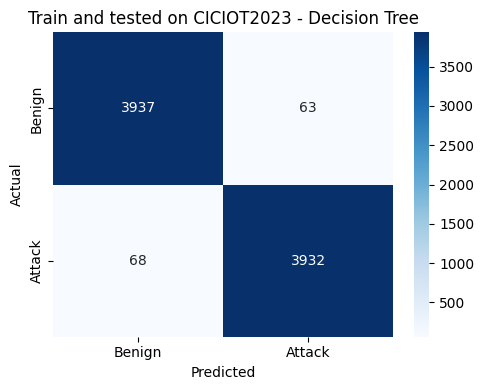

Training Random Forest....
Model Name: Random Forest
Accuracy 0.987
Precision: 0.9926656550328781
Recall: 0.98125
F1-Score: 0.9869248177017853
Training Time: 16.778913974761963 seconds
Testing Time: 0.07213497161865234 seconds


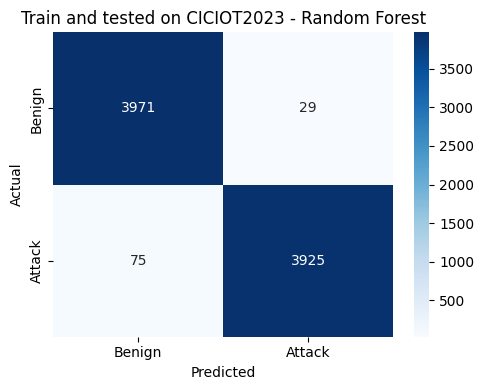

Training KNN....
Model Name: KNN
Accuracy 0.982
Precision: 0.986377396569122
Recall: 0.9775
F1-Score: 0.9819186338523355
Training Time: 0.045088768005371094 seconds
Testing Time: 1.7932770252227783 seconds


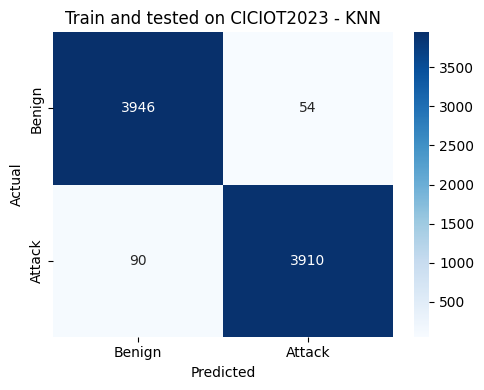

Training SVM....
Model Name: SVM
Accuracy 0.974875
Precision: 0.9984256100760955
Recall: 0.95125
F1-Score: 0.9742670592753808
Training Time: 129.78569221496582 seconds
Testing Time: 4.744954347610474 seconds


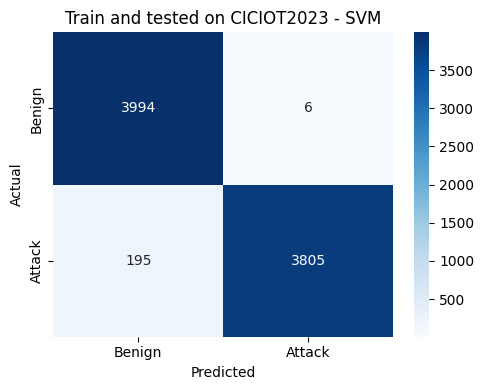

Training Logistic Regression....
Model Name: Logistic Regression
Accuracy 0.975625
Precision: 0.9981670594396439
Recall: 0.953
F1-Score: 0.9750607494564523
Training Time: 1.9854083061218262 seconds
Testing Time: 0.011042118072509766 seconds


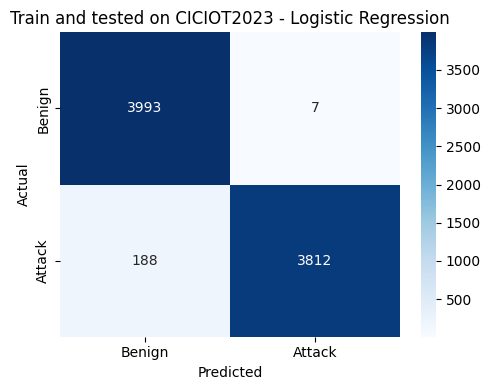

Training XGBoost....
Model Name: XGBoost
Accuracy 0.98925
Precision: 0.9902304609218436
Recall: 0.98825
F1-Score: 0.9892392392392393
Training Time: 3.2984795570373535 seconds
Testing Time: 0.022976398468017578 seconds


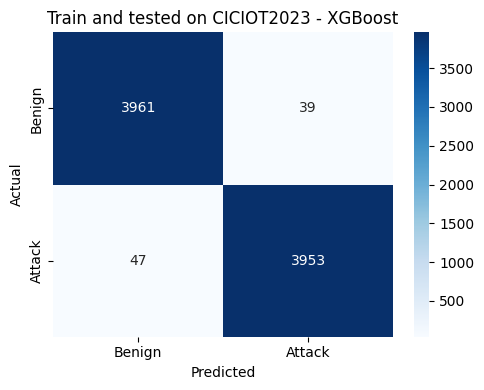

Training DNN....
Model Name: DNN
Accuracy 0.97775
Precision: 0.9992163009404389
Recall: 0.95625
F1-Score: 0.9772611139499233
Training Time: 24.17903208732605 seconds
Testing Time: 0.011626958847045898 seconds


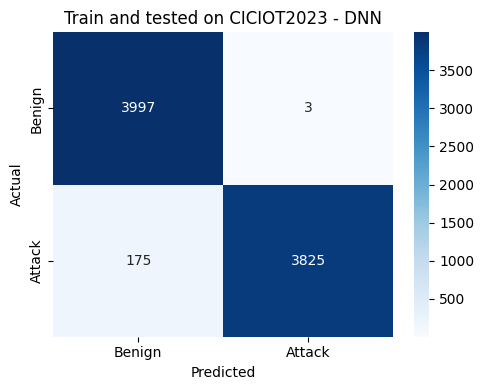


 All models are trained and evaluated


In [6]:
#Train and evaluate all models

results=[]

for model_name, model in models.items():
    print(f"Training {model_name}....")

    #train the model on train data
    start_time=time.time()
    model.fit(X_train, y_train)
    end_time=time.time()
    training_time=end_time-start_time

    #predict on test data
    start_time=time.time()
    y_pred=model.predict(X_test)
    end_time=time.time()
    testing_time=end_time-start_time
    
    #metrics calculation
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)

    #Storing results
    results.append({
         'Model': model_name,
         'Accuracy': round(accuracy,4),
         'Precision': round(precision,4),
         'Recall': round(recall,4),
         'F1-Score': round(f1,4),
         'Training Time (S)': training_time,
         'Testing Time (S)': testing_time
     })
    print(f"Model Name: {model_name}")
    print(f"Accuracy {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1-Score: {f1}")
    print(f"Training Time: {training_time} seconds")
    print(f"Testing Time: {testing_time} seconds")

    #plot confusion matrix,
    cm=confusion_matrix(y_test, y_pred)
    fig,ax=plt.subplots(figsize=(5,4))
    sbn.heatmap(
    cm, annot=True, fmt='d',cmap='Blues',
    xticklabels=['Benign', 'Attack'],
    yticklabels=['Benign', 'Attack'],
    ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f"Train and tested on CICIOT2023 - {model_name}")
    plt.tight_layout()
    plt.show()
    plt.close()
     

print("\n All models are trained and evaluated")       
    

In [7]:
results_df=pd.DataFrame(results)

results_df=results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("CICIOT2023 Model Comparision:")
print(results_df.to_string(index=False))

CICIOT2023 Model Comparision:
              Model  Accuracy  Precision  Recall  F1-Score  Training Time (S)  Testing Time (S)
            XGBoost    0.9892     0.9902  0.9882    0.9892           3.298480          0.022976
      Random Forest    0.9870     0.9927  0.9812    0.9869          16.778914          0.072135
      Decision Tree    0.9836     0.9842  0.9830    0.9836           2.659219          0.009672
                KNN    0.9820     0.9864  0.9775    0.9819           0.045089          1.793277
                DNN    0.9778     0.9992  0.9563    0.9773          24.179032          0.011627
Logistic Regression    0.9756     0.9982  0.9530    0.9751           1.985408          0.011042
                SVM    0.9749     0.9984  0.9513    0.9743         129.785692          4.744954


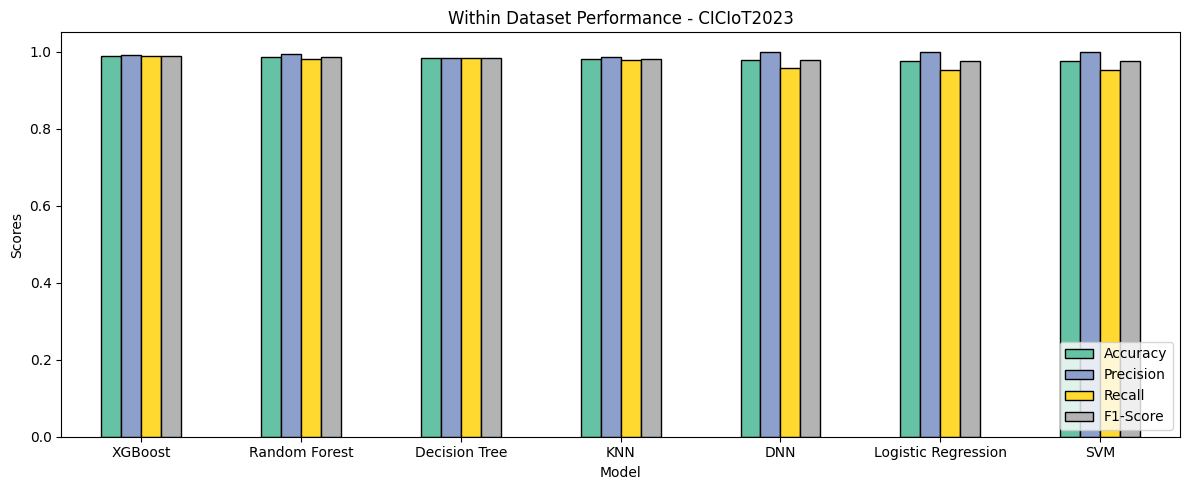

In [8]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].copy()
plot_df = plot_df.apply(pd.to_numeric, errors="coerce")

plot_df.plot(
    kind="bar",
    figsize=(12, 5),
    ylim=(0, 1.05),
    colormap="Set2",
    edgecolor="black"
)

plt.title("Within Dataset Performance - CICIoT2023")
plt.xlabel("Model")
plt.ylabel("Scores")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [9]:
#SHAP Feature Importance

#as SHAP is very slow on large datasets. A subsample of both train and test set will be taken

train_sample=shap.sample(X_train, 100, random_state=42)

test_sample=X_test.sample(200, random_state=42)

print(f"Train sample shape: {train_sample.shape}")
print(f"Test sample shape: {test_sample.shape}")


Train sample shape: (100, 102)
Test sample shape: (200, 102)


Computing SHAP values for Decision Tree...


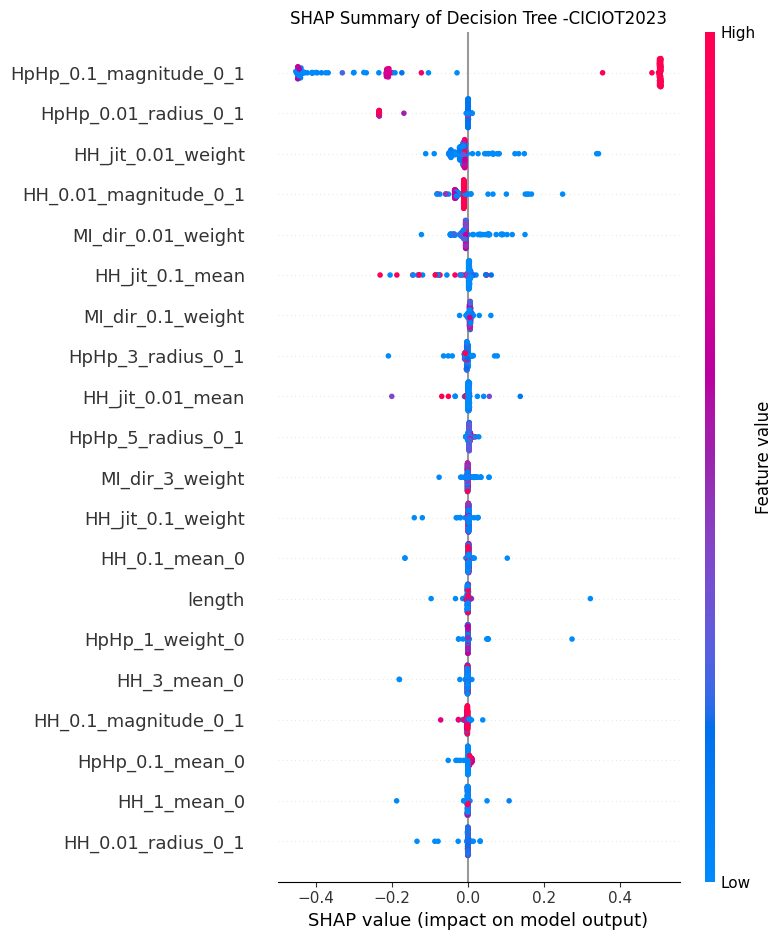

Computing SHAP values for Random Forest...


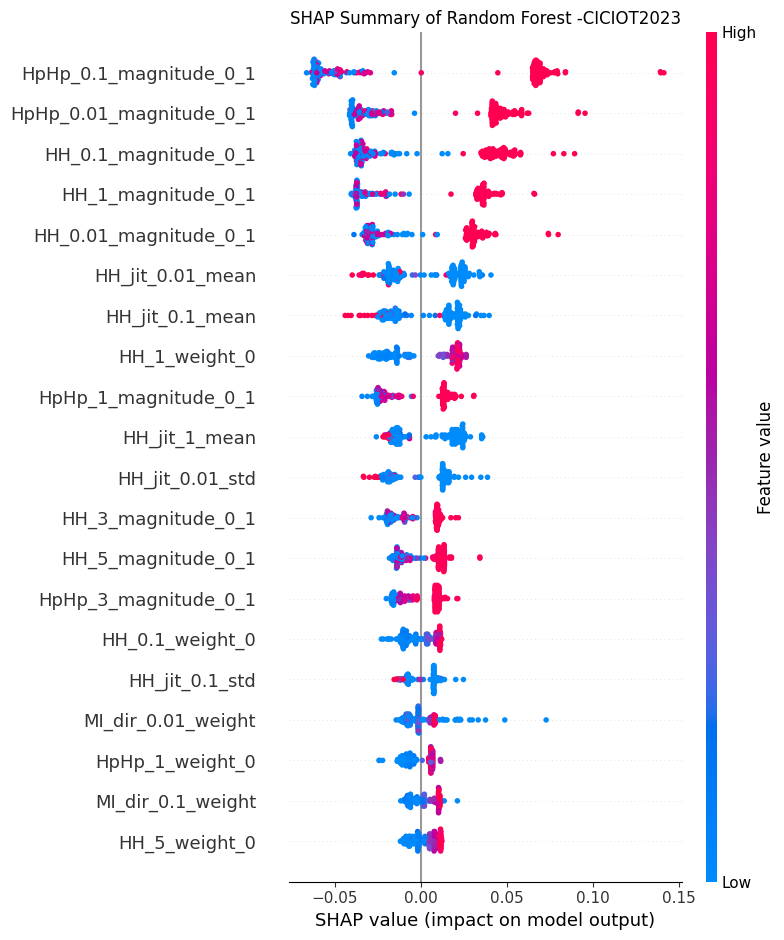

Computing SHAP values for XGBoost...


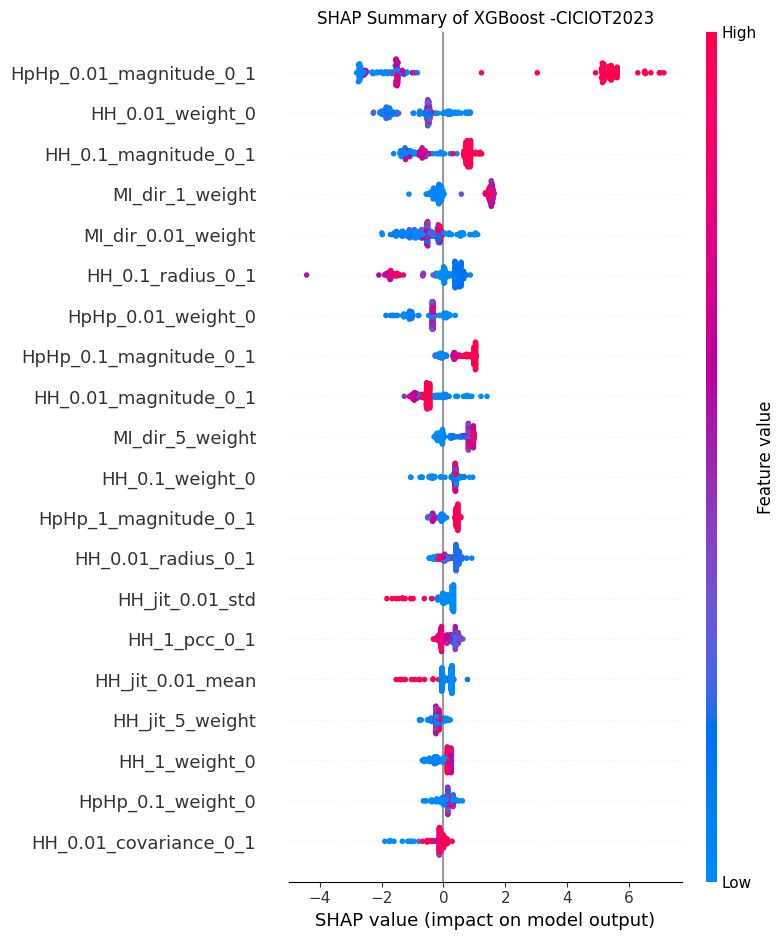

Tree-based SHAP values are calculated

Top 20 features for Decision Tree (CICIoT2023): 
               Feature  Mean SHAP
HpHp_0.1_magnitude_0_1   0.421844
  HpHp_0.01_radius_0_1   0.037538
    HH_jit_0.01_weight   0.026993
 HH_0.01_magnitude_0_1   0.025776
    MI_dir_0.01_weight   0.018372
       HH_jit_0.1_mean   0.014708
     MI_dir_0.1_weight   0.006020
     HpHp_3_radius_0_1   0.005765
      HH_jit_0.01_mean   0.004855
     HpHp_5_radius_0_1   0.004237
       MI_dir_3_weight   0.004211
     HH_jit_0.1_weight   0.004089
         HH_0.1_mean_0   0.003854
                length   0.003462
       HpHp_1_weight_0   0.003134
           HH_3_mean_0   0.003012
  HH_0.1_magnitude_0_1   0.002898
       HpHp_0.1_mean_0   0.002758
           HH_1_mean_0   0.002566
    HH_0.01_radius_0_1   0.002527

Top 20 features for Random Forest (CICIoT2023): 
                Feature  Mean SHAP
 HpHp_0.1_magnitude_0_1   0.061872
HpHp_0.01_magnitude_0_1   0.039802
   HH_0.1_magnitude_0_1   0.038338
     HH_

In [10]:
#SHAP for tree-based models (Decision Tree, Random Forest and XGBoost)

tree_based_models = ["Decision Tree", "Random Forest", "XGBoost"]
tree_shap_values={}

for model_name in tree_based_models:
    print(f"Computing SHAP values for {model_name}...")
    explainer=shap.TreeExplainer(models[model_name])
    shap_values=explainer.shap_values(test_sample)

    shap_values=np.array(shap_values)
    if shap_values.ndim==3:
        shap_values=shap_values[:,:,1]

    tree_shap_values[model_name]=shap_values

    plt.figure()
    shap.summary_plot(shap_values, test_sample, show=False)
    plt.title(f"SHAP Summary of {model_name} -CICIOT2023")
    plt.tight_layout()
    plt.show()

print("Tree-based SHAP values are calculated")


tree_imporatnce_table= {}
for model_name, shap_values in tree_shap_values.items():
    mean_abs_shap=np.abs(shap_values).mean(axis=0)
    importance_df=pd.DataFrame({"Feature":test_sample.columns,
                               "Mean SHAP":mean_abs_shap
                               }).sort_values("Mean SHAP", ascending=False).reset_index(drop=True)
    tree_imporatnce_table[model_name]=importance_df
    print(f"\nTop 20 features for {model_name} (CICIoT2023): ")
    print(importance_df.head(20).to_string(index=False))

Background dataset has 32000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=32000 when initializing the masker.


Computing SHAP values for Logistic Regression...


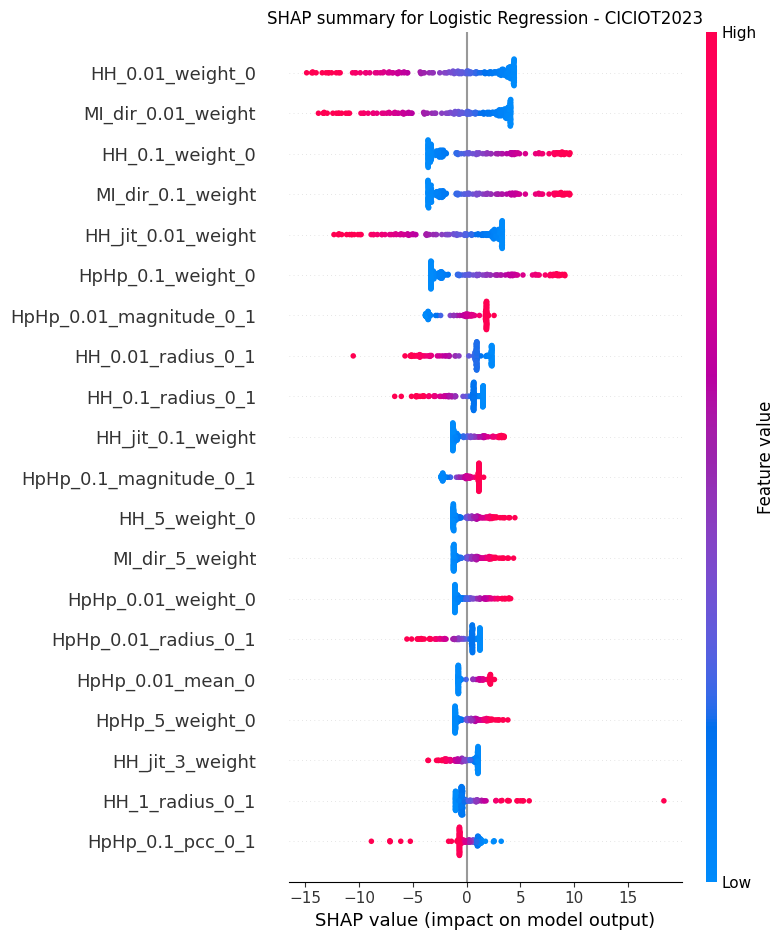


Top 20 features for Logistic Regression (CICIoT2023):
                Feature  Mean SHAP
       HH_0.01_weight_0   4.269743
     MI_dir_0.01_weight   3.957133
        HH_0.1_weight_0   3.719661
      MI_dir_0.1_weight   3.719026
     HH_jit_0.01_weight   3.586234
      HpHp_0.1_weight_0   3.553793
HpHp_0.01_magnitude_0_1   2.020534
     HH_0.01_radius_0_1   1.991559
      HH_0.1_radius_0_1   1.372922
      HH_jit_0.1_weight   1.361449
 HpHp_0.1_magnitude_0_1   1.248773
          HH_5_weight_0   1.245920
        MI_dir_5_weight   1.212162
     HpHp_0.01_weight_0   1.192543
   HpHp_0.01_radius_0_1   1.121136
       HpHp_0.01_mean_0   1.100397
        HpHp_5_weight_0   1.066288
        HH_jit_3_weight   1.043452
        HH_1_radius_0_1   0.988270
       HpHp_0.1_pcc_0_1   0.975523


In [11]:
#SHAP for Logistic Regression

print("Computing SHAP values for Logistic Regression...")
lr_explainer=shap.LinearExplainer(models['Logistic Regression'], X_train, max_samples=32000)
lr_shap_values=lr_explainer.shap_values(test_sample)

plt.figure()
shap.summary_plot(lr_shap_values, test_sample, show=False)
plt.title("SHAP summary for Logistic Regression - CICIOT2023")
plt.tight_layout()
plt.show()

mean_abs_shap = np.abs(lr_shap_values).mean(axis=0)
lr_importance_df = pd.DataFrame({
    "Feature": test_sample.columns,
    "Mean SHAP": mean_abs_shap
}).sort_values("Mean SHAP", ascending=False).reset_index(drop=True)
print("\nTop 20 features for Logistic Regression (CICIoT2023):")
print(lr_importance_df.head(20).to_string(index=False))

Computing SHAP values for KNN...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [40:20<00:00, 48.41s/it]


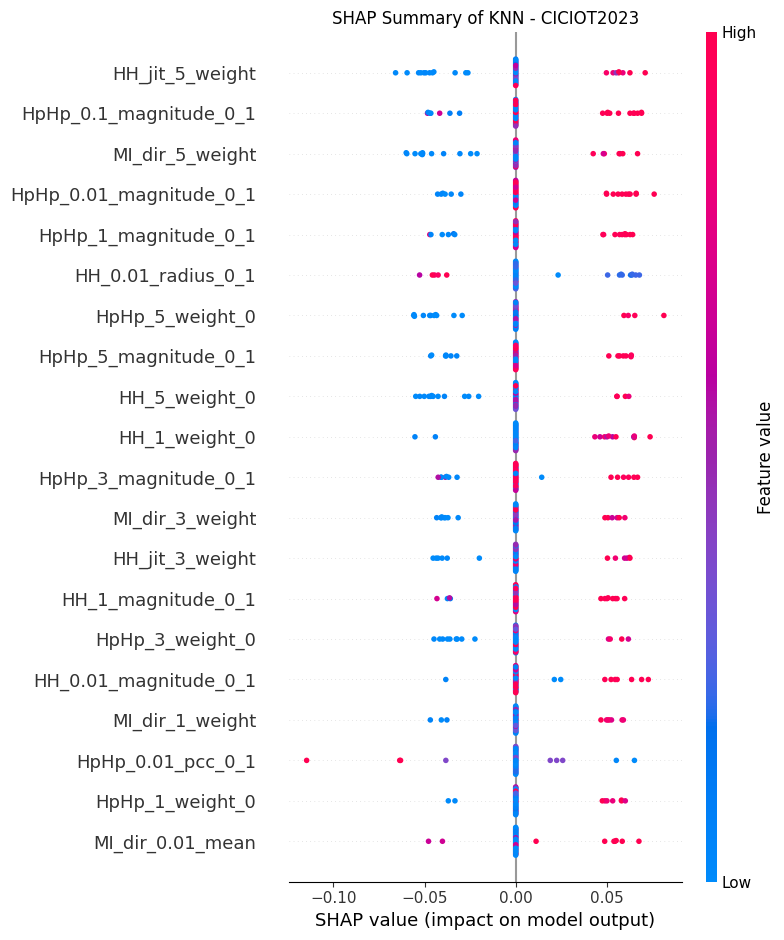

Computing SHAP values for SVM...


100%|███████████████████████████████████████████████████████████████████████████████| 50/50 [2:04:35<00:00, 149.50s/it]


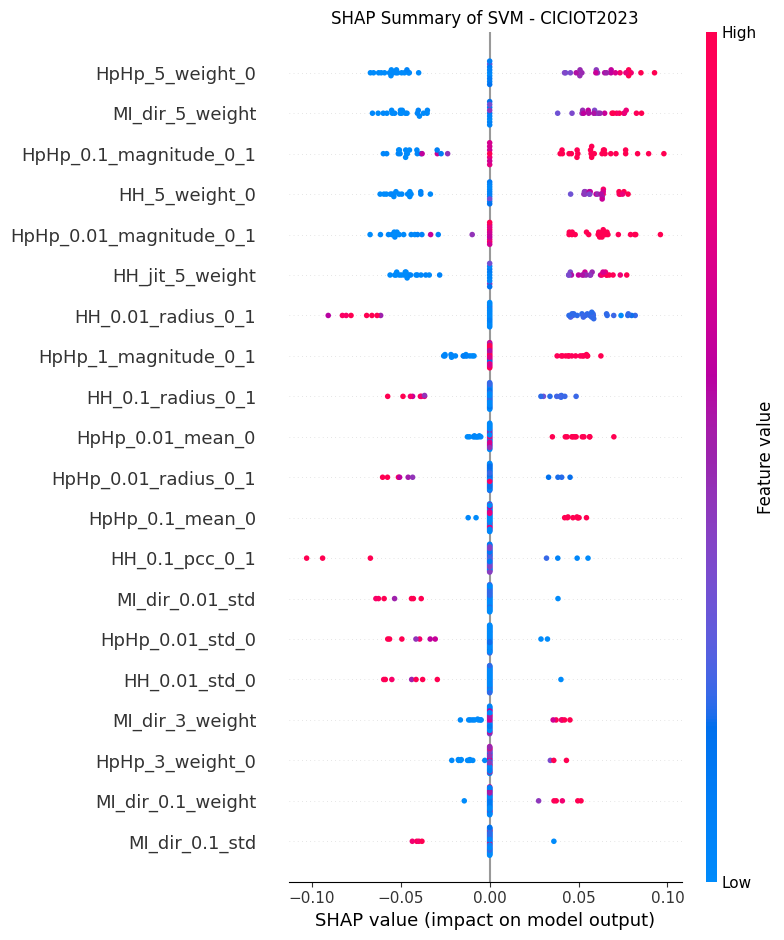

KN Nand SVM SHAP values are calculated

Top 20 features for KNN (CICIoT2023):
                Feature  Mean SHAP
        HH_jit_5_weight   0.020377
 HpHp_0.1_magnitude_0_1   0.019043
        MI_dir_5_weight   0.018431
HpHp_0.01_magnitude_0_1   0.017775
   HpHp_1_magnitude_0_1   0.016234
     HH_0.01_radius_0_1   0.015895
        HpHp_5_weight_0   0.015493
   HpHp_5_magnitude_0_1   0.014980
          HH_5_weight_0   0.014646
          HH_1_weight_0   0.014311
   HpHp_3_magnitude_0_1   0.012900
        MI_dir_3_weight   0.012740
        HH_jit_3_weight   0.011605
     HH_1_magnitude_0_1   0.011451
        HpHp_3_weight_0   0.010789
  HH_0.01_magnitude_0_1   0.010022
        MI_dir_1_weight   0.009877
      HpHp_0.01_pcc_0_1   0.009347
        HpHp_1_weight_0   0.008923
       MI_dir_0.01_mean   0.008750

Top 20 features for SVM (CICIoT2023):
                Feature  Mean SHAP
        HpHp_5_weight_0   0.049223
        MI_dir_5_weight   0.046553
 HpHp_0.1_magnitude_0_1   0.045783
        

In [12]:
#SHAP for KNN and SVM

kernel_models = ["KNN", "SVM"]
kernel_sample=test_sample.sample(50, random_state=42)
kernel_shap_values = {}

for model_name in kernel_models:
    print(f"Computing SHAP values for {model_name}...")
    model=models[model_name]

    k_explainer=shap.KernelExplainer(model.predict_proba, train_sample)
    shap_values=k_explainer.shap_values(kernel_sample, nsample=100)

    shap_values=np.array(shap_values)
    if shap_values.ndim==3:
        shap_values=shap_values[:,:,1]

    kernel_shap_values[model_name]=shap_values

    plt.figure()
    shap.summary_plot(shap_values, kernel_sample, show=False)
    plt.title(f"SHAP Summary of {model_name} - CICIOT2023")
    plt.tight_layout()
    plt.show()

print("KN Nand SVM SHAP values are calculated")

kernel_importance_tables = {}
for model_name, shap_values in kernel_shap_values.items():
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        "Feature": kernel_sample.columns,
        "Mean SHAP": mean_abs_shap
    }).sort_values("Mean SHAP", ascending=False).reset_index(drop=True)
    kernel_importance_tables[model_name] = importance_df
    print(f"\nTop 20 features for {model_name} (CICIoT2023):")
    print(importance_df.head(20).to_string(index=False))

Computing SHAP values for DNN...


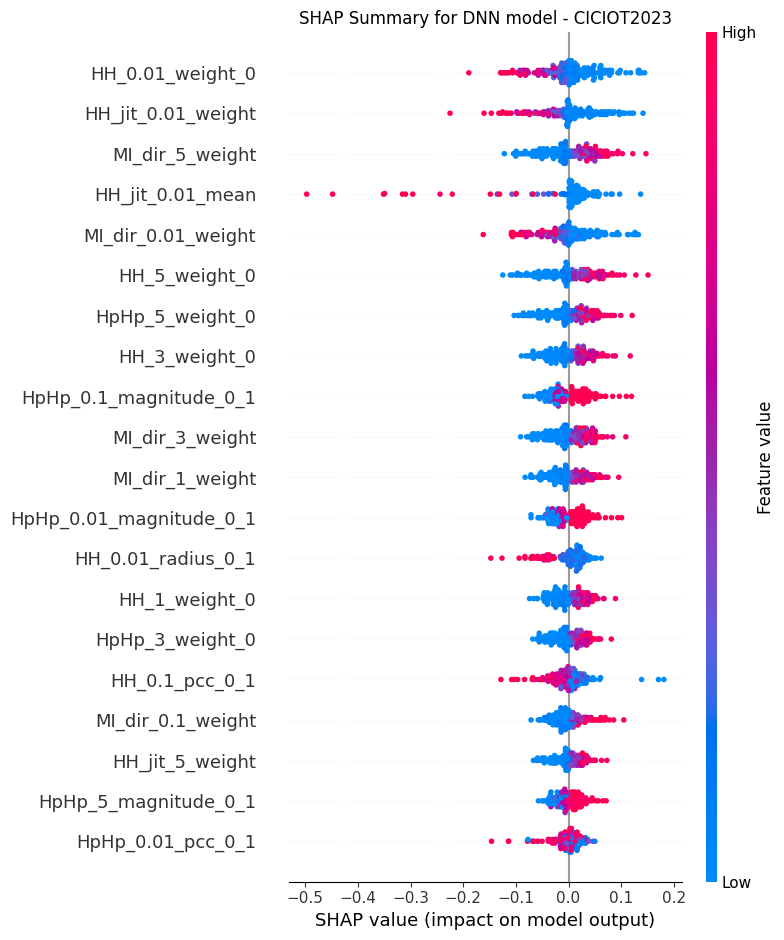

DNN SHAP values are calculated.

Top 20 features for DNN (CICIoT2023):
                Feature  Mean SHAP
       HH_0.01_weight_0   0.040076
     HH_jit_0.01_weight   0.039228
        MI_dir_5_weight   0.039022
       HH_jit_0.01_mean   0.038637
     MI_dir_0.01_weight   0.036325
          HH_5_weight_0   0.036240
        HpHp_5_weight_0   0.032645
          HH_3_weight_0   0.029474
 HpHp_0.1_magnitude_0_1   0.029464
        MI_dir_3_weight   0.029022
        MI_dir_1_weight   0.026416
HpHp_0.01_magnitude_0_1   0.025667
     HH_0.01_radius_0_1   0.024339
          HH_1_weight_0   0.024288
        HpHp_3_weight_0   0.023534
         HH_0.1_pcc_0_1   0.022156
      MI_dir_0.1_weight   0.021198
        HH_jit_5_weight   0.019046
   HpHp_5_magnitude_0_1   0.018810
      HpHp_0.01_pcc_0_1   0.017239


In [13]:
#SHAP for DNN model

print("Computing SHAP values for DNN...")

dnn_model=models["DNN"].model_
dnn_model.eval()

train_sample_t=torch.tensor(train_sample.values.astype('float32'))
test_sample_t=torch.tensor(test_sample.values.astype('float32'))

dnn_explainer=shap.GradientExplainer(dnn_model, test_sample_t)
dnn_shap_values=dnn_explainer.shap_values(test_sample_t)

if isinstance(dnn_shap_values, list):
    dnn_shap_values=dnn_shap_values[0]

dnn_shap_values=np.squeeze(dnn_shap_values)

plt.figure()
shap.summary_plot(dnn_shap_values, test_sample, show=False)
plt.title("SHAP Summary for DNN model - CICIOT2023")
plt.tight_layout()
plt.show()

print("DNN SHAP values are calculated.")

mean_abs_shap = np.abs(dnn_shap_values).mean(axis=0)
dnn_importance_df = pd.DataFrame({
    "Feature": test_sample.columns,
    "Mean SHAP": mean_abs_shap
}).sort_values("Mean SHAP", ascending=False).reset_index(drop=True)
print("\nTop 20 features for DNN (CICIoT2023):")
print(dnn_importance_df.head(20).to_string(index=False))

In [15]:
# Combine top-20 feature sets from all 7 models and print the common (intersection) features
all_top20 = {}

for model_name, df in tree_imporatnce_table.items():
    all_top20[model_name] = set(df["Feature"].head(20))

all_top20["Logistic Regression"] = set(lr_importance_df["Feature"].head(20))

for model_name, df in kernel_importance_tables.items():
    all_top20[model_name] = set(df["Feature"].head(20))

all_top20["DNN"] = set(dnn_importance_df["Feature"].head(20))

print(f"Models included in intersection: {list(all_top20.keys())}\n")

common_features = set.intersection(*all_top20.values())
print(f"Features in top20 across all {len(all_top20)} models are: {common_features}")

# How many of the models each feature appears in (if the above intersection is empty or very small)
from collections import Counter
feature_counts = Counter()
for features in all_top20.values():
    for f in features:
        feature_counts[f] += 1

coverage_df = pd.DataFrame(
    feature_counts.most_common(),
    columns=["Feature", "Models".format(len(all_top20))]
)
print("\nFeature coverage across all models (CICIoT2023), most consistent first:")
print(coverage_df.to_string(index=False))

Models included in intersection: ['Decision Tree', 'Random Forest', 'XGBoost', 'Logistic Regression', 'KNN', 'SVM', 'DNN']

Features in top20 across all 7 models are: {'HpHp_0.1_magnitude_0_1'}

Feature coverage across all models (CICIoT2023), most consistent first:
                Feature  Models
 HpHp_0.1_magnitude_0_1       7
     HH_0.01_radius_0_1       6
HpHp_0.01_magnitude_0_1       6
     MI_dir_0.01_weight       5
      MI_dir_0.1_weight       5
          HH_5_weight_0       5
        MI_dir_5_weight       5
        MI_dir_3_weight       4
  HH_0.01_magnitude_0_1       4
       HH_jit_0.01_mean       4
          HH_1_weight_0       4
   HpHp_1_magnitude_0_1       4
        HH_jit_5_weight       4
        HpHp_5_weight_0       4
        HpHp_1_weight_0       3
     HH_jit_0.01_weight       3
   HpHp_0.01_radius_0_1       3
   HH_0.1_magnitude_0_1       3
        HH_0.1_weight_0       3
       HH_0.01_weight_0       3
      HH_0.1_radius_0_1       3
        MI_dir_1_weight      